# 02 · Exploratory analysis and statistics

Analysis window **1 Aug - 15 Sep 2016** (46 days), as-of date 16 Sep 2016. Source tables: `fact_transaction`,
`customer_360` (one row per CustomerID). Each chart is followed by *what we found · why it matters · what a manager should do*.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from c360 import db, viz
from c360.config import FIG_DIR
viz.apply_style()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 50)

In [2]:
c = db.query("SELECT * FROM customer_360")
amounts = db.query("SELECT amount FROM fact_transaction")["amount"].astype(float)
for col in ["total_txn_value", "avg_txn_value", "avg_balance", "latest_balance", "max_balance",
            "engagement_score", "value_score", "txn_to_balance_ratio", "balance_volatility"]:
    c[col] = c[col].astype(float)
print(f"{len(c):,} customers · {len(amounts):,} transactions · total value Rs {amounts.sum():,.0f}")

841,543 customers · 988,947 transactions · total value Rs 1,554,774,113


## P1 · Transaction amount distribution

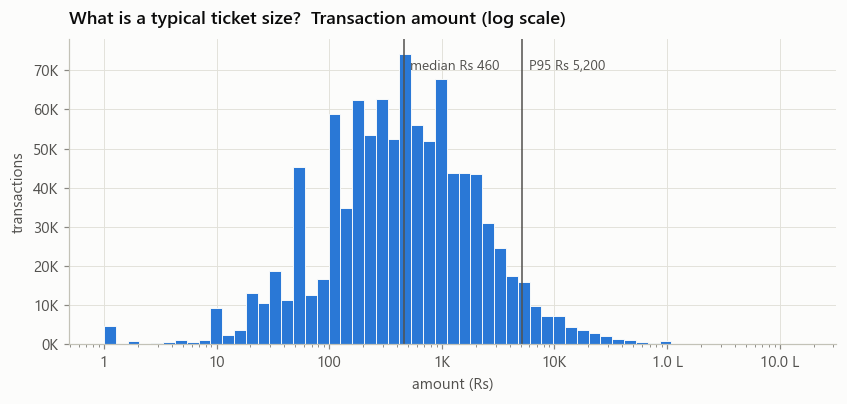

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.6))
bins = np.logspace(0, np.log10(amounts.max()), 60)
ax.hist(amounts, bins=bins, color=viz.SERIES[0], edgecolor=viz.SURFACE, linewidth=0.6)
ax.set_xscale("log"); ax.xaxis.set_major_formatter(mticker.FuncFormatter(viz.inr))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
for q, lab in [(0.5, "median"), (0.95, "P95")]:
    v = amounts.quantile(q); ax.axvline(v, color=viz.INK_2, linewidth=1)
    ax.annotate(f"{lab} Rs {v:,.0f}", (v, ax.get_ylim()[1] * 0.9), xytext=(4, 0), textcoords="offset points", fontsize=9, color=viz.INK_2)
ax.set_title("What is a typical ticket size?  Transaction amount (log scale)")
ax.set_xlabel("amount (Rs)"); ax.set_ylabel("transactions")
viz.save(fig, "P1_amount_distribution"); fig

In [4]:
amounts.describe(percentiles=[.25, .5, .75, .9, .95, .99]).to_frame('amount (Rs)').T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
amount (Rs),"988,947.00","1,572.15","6,558.13",0.01,163.00,460.00,"1,200.00","2,941.00","5,199.99","20,000.00","1,560,034.99"


**What we found.** Ticket sizes are heavily right-skewed: the median transaction is Rs 460, the mean Rs 1,572, the 95th percentile Rs 5,200 and the largest Rs 15.6 lakh.

**Why it matters.** Averages overstate the typical customer; any segmentation on raw amounts would be driven by a few very large tickets.

**What a manager should do.** Read medians and bands, not means, and treat transactions above P95 (Rs 5,200, rule BR-07) as a separate high-value-transaction view.

## P2 · Balance distribution (customers)

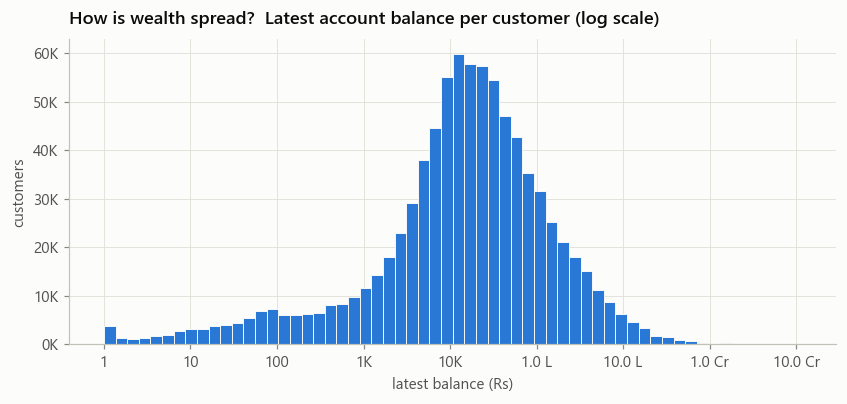

In [5]:
b = c["latest_balance"].dropna()
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(np.log10(b + 1), bins=60, color=viz.SERIES[0], edgecolor=viz.SURFACE, linewidth=0.6)
ticks = [0, 1, 2, 3, 4, 5, 6, 7, 8]
ax.set_xticks(ticks, [viz.inr(10 ** t) for t in ticks])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.set_title("How is wealth spread?  Latest account balance per customer (log scale)")
ax.set_xlabel("latest balance (Rs)"); ax.set_ylabel("customers")
viz.save(fig, "P2_balance_distribution"); fig

In [6]:
pd.Series({"median latest balance": b.median(), "mean latest balance": b.mean(),
           "P90": b.quantile(.9), "P99": b.quantile(.99),
           "zero / near-zero balance customers (%)": 100 * (b < 1).mean(),
           "top 10% share of total balance (%)": 100 * b.nlargest(int(len(b) * .1)).sum() / b.sum()},
          name="value").to_frame()

,value
median latest balance,"16,676.23"
mean latest balance,"114,919.76"
P90,"197,671.55"
P99,"1,577,984.15"
zero / near-zero balance customers (%),0.64
top 10% share of total balance (%),76.83


**What we found.** Latest balances span from zero to over Rs 10 crore. The median is Rs 16,676 against a mean of Rs 1.15 lakh, and the top 10% of customers hold **76.8% of all balance**. Only 0.6% of customers have a zero or near-zero balance.

**Why it matters.** Deposit value sits with a small group, so service quality for that group carries most of the balance-sheet risk and opportunity.

**What a manager should do.** Give the top balance decile (P90 = Rs 1.98 lakh) named relationship coverage; use the log scale in every balance chart.

## P3 · Transactions per customer

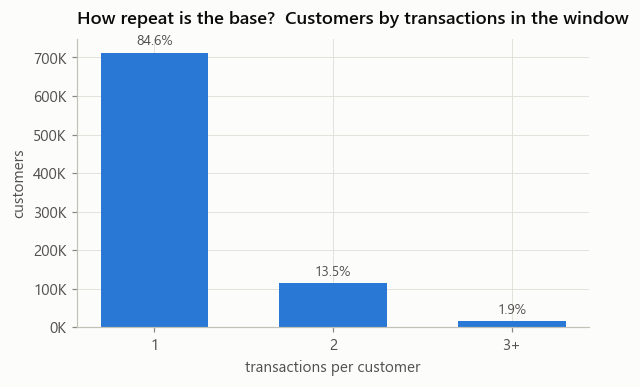

In [7]:
dist = c["txn_count"].clip(upper=3).map({1: "1", 2: "2", 3: "3+"}).value_counts().reindex(["1", "2", "3+"])
fig, ax = plt.subplots(figsize=(6, 3.4))
bars = ax.bar(dist.index, dist.values, color=viz.SERIES[0], width=0.6)
for r, v in zip(bars, dist.values):
    ax.annotate(f"{100 * v / dist.sum():.1f}%", (r.get_x() + r.get_width() / 2, v), ha="center", va="bottom",
                xytext=(0, 3), textcoords="offset points", fontsize=9, color=viz.INK_2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.set_title("How repeat is the base?  Customers by transactions in the window")
ax.set_xlabel("transactions per customer"); ax.set_ylabel("customers")
viz.save(fig, "P3_txns_per_customer"); fig

**What we found.** 84.6% of customers made a single transaction in the 46-day window, 13.5% made two and 1.9% three or more.

**Why it matters.** For most customers, frequency, recency and trend rest on one observation. In addition, notebook 01 showed repeat CustomerIDs rarely keep the same DOB, gender or city, so repeat behaviour is weak evidence.

**What a manager should do.** Treat the evidence level (Low = one transaction) as part of every list; prioritise outreach on balance and ticket size rather than on frequency.

## P4 · Age distribution

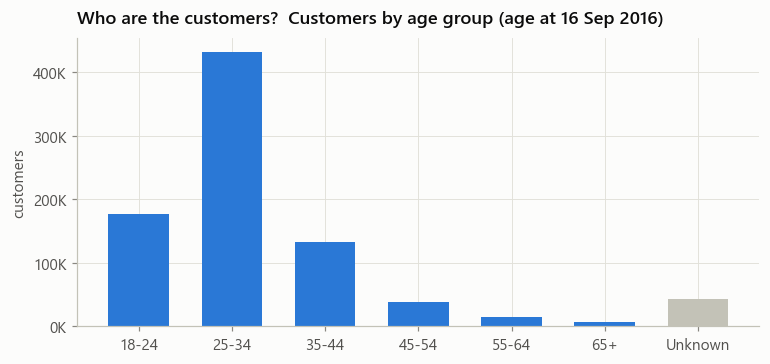

In [8]:
order = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+", "Unknown"]
ag = c["age_group"].value_counts().reindex(order)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(ag.index, ag.values, color=[viz.SERIES[0]] * 6 + [viz.AXIS], width=0.65)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.set_title("Who are the customers?  Customers by age group (age at 16 Sep 2016)")
ax.set_ylabel("customers")
viz.save(fig, "P4_age_distribution"); fig

In [9]:
(100 * ag / ag.sum()).round(1).to_frame('% of customers').T

age_group,18-24,25-34,35-44,45-54,55-64,65+,Unknown
% of customers,21.00,51.30,15.70,4.60,1.70,0.80,5.10


**What we found.** The base is young: 51.3% are 25-34 and 21.0% are 18-24; only 7.1% are 45 or older. 5.1% have an unknown age (placeholder or invalid DOB).

**Why it matters.** Product themes that depend on life stage (insurance, investment) apply to a minority, while digital-first and credit products fit the majority profile.

**What a manager should do.** Lead with products that suit customers in their twenties and early thirties, and do not run age-based campaigns on the 5.1% with unknown age.

## P5 · Average ticket by gender

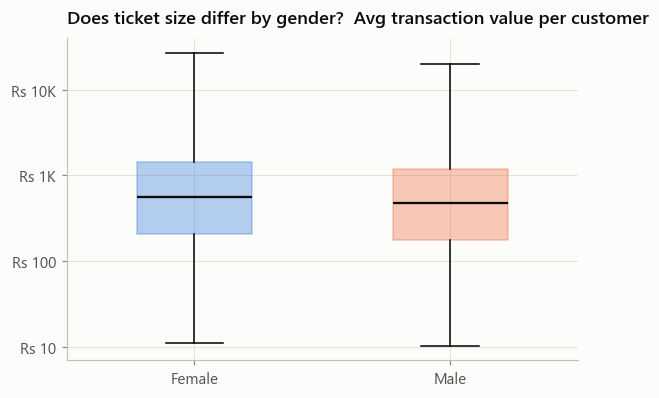

In [10]:
g = c[c["gender"].isin(["M", "F"])]
fig, ax = plt.subplots(figsize=(6, 3.8))
data = [np.log10(g.loc[g.gender == s, "avg_txn_value"]) for s in ["F", "M"]]
bp = ax.boxplot(data, tick_labels=["Female", "Male"], widths=0.45, showfliers=False, patch_artist=True,
                medianprops=dict(color=viz.INK, linewidth=1.5))
for patch, col in zip(bp["boxes"], [viz.SERIES[0], viz.SERIES[1]]):
    patch.set_facecolor(col); patch.set_alpha(0.35); patch.set_edgecolor(col)
ax.set_yticks([1, 2, 3, 4], ["Rs 10", "Rs 100", "Rs 1K", "Rs 10K"])
ax.set_title("Does ticket size differ by gender?  Avg transaction value per customer")
viz.save(fig, "P5_gender_ticket"); fig

In [11]:
g.groupby('gender')['avg_txn_value'].describe(percentiles=[.25, .5, .75])

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
F,"224,588.00","1,653.24","6,406.89",0.01,205.00,560.00,"1,441.00","1,380,002.88"
M,"616,169.00","1,540.49","6,430.02",0.01,177.00,473.00,"1,176.40","1,560,034.99"


**What we found.** Women have a slightly higher typical ticket than men (median Rs 560 vs Rs 473). The Mann-Whitney test is significant but the effect is small (rank-biserial r = 0.08).

**Why it matters.** Gender explains almost none of the variation in spend, which supports leaving gender out of the clustering inputs (risk R8).

**What a manager should do.** Do not target by gender; use gender only to check that segments and lists are balanced.

## P6 · Top 15 cities by transaction value

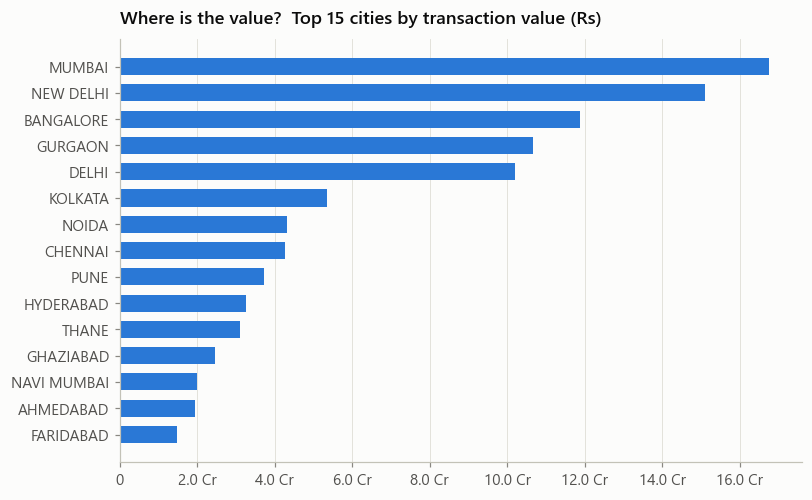

In [12]:
city = (c[c.clean_city != "UNKNOWN"].groupby("clean_city")
        .agg(customers=("customer_id", "size"), value=("total_txn_value", "sum")).sort_values("value", ascending=False))
city["value_share_%"] = 100 * city["value"] / c["total_txn_value"].sum()
top = city.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top["value"], color=viz.SERIES[0], height=0.65)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(viz.inr))
ax.grid(axis="y", visible=False)
ax.set_title("Where is the value?  Top 15 cities by transaction value (Rs)")
viz.save(fig, "P6_top_cities"); fig

In [13]:
print(f"Top 5 cities hold {city['value_share_%'].head(5).sum():.1f}% of value; top 15 hold {city['value_share_%'].head(15).sum():.1f}%")
city.head(15).style.format({"customers": "{:,.0f}", "value": "{:,.0f}", "value_share_%": "{:.2f}"})

Top 5 cities hold 41.6% of value; top 15 hold 62.1%


,customers,value,value_share_%
clean_city,,,
MUMBAI,"83,174","167,735,425",10.79
NEW DELHI,"68,600","150,990,670",9.71
BANGALORE,"67,756","118,907,045",7.65
GURGAON,"59,638","106,668,072",6.86
DELHI,"56,866","101,919,767",6.56
KOLKATA,"16,047","53,347,984",3.43
NOIDA,"26,274","43,063,168",2.77
CHENNAI,"24,205","42,649,868",2.74
PUNE,"20,656","37,327,244",2.40


**What we found.** Mumbai (10.8%), New Delhi (9.7%), Bangalore (7.6%), Gurgaon (6.9%) and Delhi (6.6%) together hold 41.6% of transaction value; the top 15 cities hold 62.1%. Kolkata has fewer customers but high value per customer.

**Why it matters.** Outreach capacity should follow value concentration, but a long tail of ~8,900 locations still holds about 38% of value.

**What a manager should do.** Staff the five metro hubs first, and use the city scorecard (Page 3 and Excel sheet 4) to find smaller cities with high value per customer.

## P7 · Daily activity trend

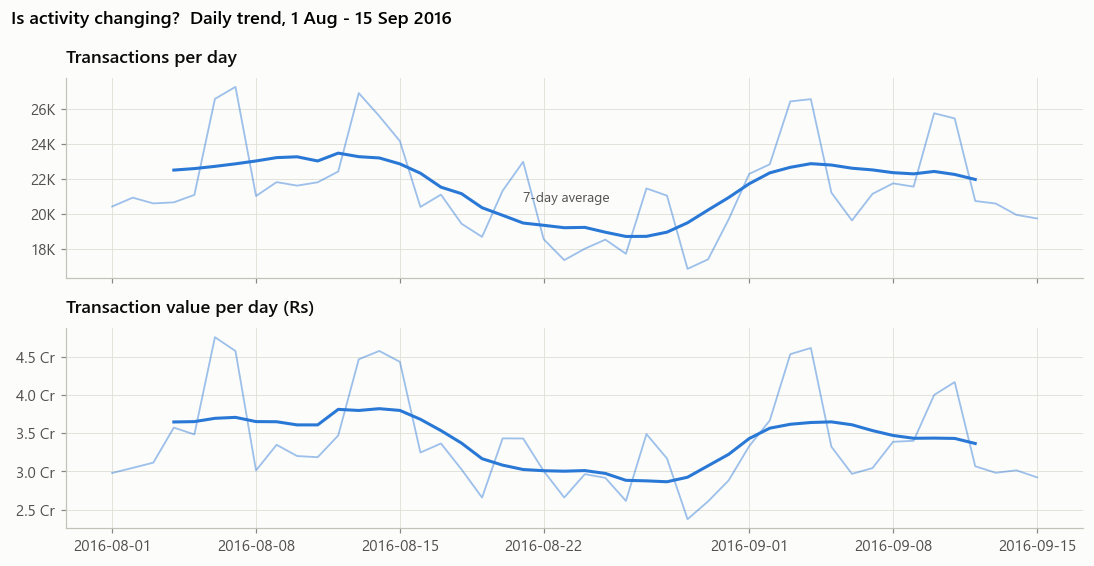

In [14]:
daily = db.query("""SELECT d.date, COUNT(*) AS txns, SUM(f.amount) AS value
                     FROM fact_transaction f JOIN dim_date d USING (date_key) GROUP BY d.date ORDER BY d.date""")
daily["date"] = pd.to_datetime(daily["date"]); daily["value"] = daily["value"].astype(float)
fig, axes = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)
for ax, col, title, fmt in [(axes[0], "txns", "Transactions per day", lambda x, _: f"{x/1000:.0f}K"),
                            (axes[1], "value", "Transaction value per day (Rs)", viz.inr)]:
    ax.plot(daily["date"], daily[col], color=viz.SERIES[0], linewidth=1.2, alpha=0.45)
    ax.plot(daily["date"], daily[col].rolling(7, center=True).mean(), color=viz.SERIES[0], linewidth=2)
    ax.set_title(title); ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
axes[0].annotate("7-day average", (daily["date"].iloc[20], daily["txns"].rolling(7, center=True).mean().iloc[20]),
                 xytext=(0, 14), textcoords="offset points", fontsize=9, color=viz.INK_2)
fig.suptitle("Is activity changing?  Daily trend, 1 Aug - 15 Sep 2016", x=0.01, ha="left", fontweight="semibold")
fig.tight_layout()
viz.save(fig, "P7_daily_trend"); fig

In [15]:
daily["weekend"] = daily["date"].dt.dayofweek >= 5
daily.groupby("weekend")[["txns", "value"]].mean().rename(index={False: "weekday", True: "weekend"})

,txns,value
weekend,,
weekday,"20,344.56","31,260,739.50"
weekend,"24,769.33","40,992,414.20"


**What we found.** Activity is flat across the window with a clear weekly rhythm: weekends average 24.8K transactions a day against 20.3K on weekdays (+22%), and weekend value is 31% higher.

**Why it matters.** A 46-day window shows no trend, only weekly seasonality. Any "declining" signal must be read against that rhythm.

**What a manager should do.** Plan campaign launches and service capacity around weekends; do not claim growth or decline from this window (limitation R1).

## P8 · Hour of day × day of week

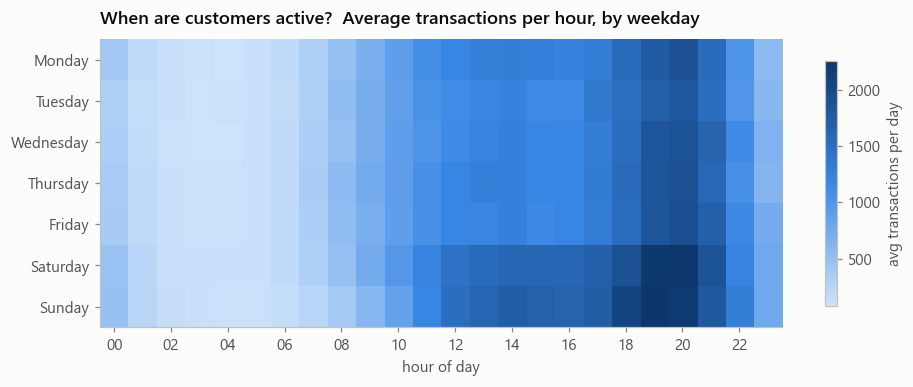

In [16]:
hw = db.query("""SELECT d.day_of_week_num, d.day_of_week, f.txn_hour, COUNT(*)::FLOAT / COUNT(DISTINCT d.date) AS txns_per_day
                  FROM fact_transaction f JOIN dim_date d USING (date_key)
                  GROUP BY d.day_of_week_num, d.day_of_week, f.txn_hour""")
grid = hw.pivot_table(index=["day_of_week_num", "day_of_week"], columns="txn_hour", values="txns_per_day").fillna(0)
from matplotlib.colors import LinearSegmentedColormap
seq = LinearSegmentedColormap.from_list("blue", [viz.BLUE[100], viz.BLUE[400], viz.BLUE[700]])
fig, ax = plt.subplots(figsize=(10, 3.4))
im = ax.imshow(grid.values, aspect="auto", cmap=seq)
ax.set_yticks(range(7), [d for _, d in grid.index]); ax.set_xticks(range(0, 24, 2), [f"{h:02d}" for h in range(0, 24, 2)])
ax.grid(False); ax.set_xlabel("hour of day")
fig.colorbar(im, ax=ax, label="avg transactions per day", shrink=0.85)
ax.set_title("When are customers active?  Average transactions per hour, by weekday")
viz.save(fig, "P8_hour_weekday"); fig

In [17]:
by_hour = hw.groupby("txn_hour")["txns_per_day"].sum()
band = pd.cut(by_hour.index, [-1, 5, 11, 16, 20, 23], labels=["00-05", "06-11", "12-16", "17-20", "21-23"])
(100 * by_hour.groupby(band, observed=True).sum() / by_hour.sum()).round(1).to_frame("% of transactions").T

,00-05,06-11,12-16,17-20,21-23
% of transactions,4.60,16.90,30.40,32.20,15.90


**What we found.** Activity peaks in the afternoon and evening: 30.4% of transactions fall between 12:00 and 16:59 and 32.2% between 17:00 and 20:59; only 4.6% are between midnight and 06:00.

**Why it matters.** Customers are most engaged with their accounts in the afternoon and early evening.

**What a manager should do.** Schedule outbound calls and digital nudges for 12:00-21:00, with weekend afternoons as the prime slot.

## P9 · Value concentration (Lorenz / Pareto)

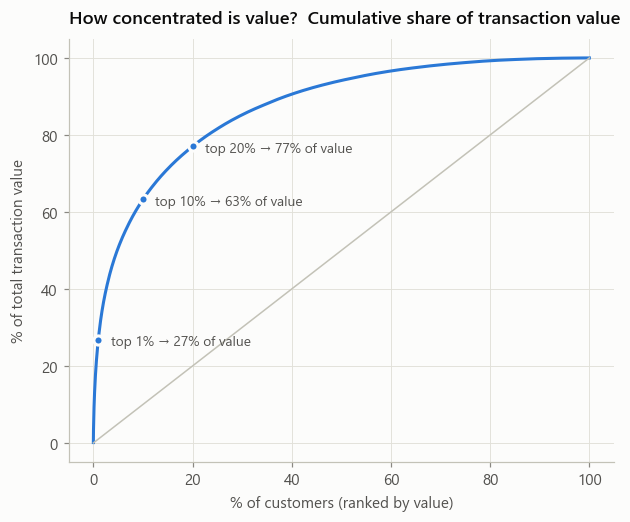

In [18]:
v = np.sort(c["total_txn_value"].values)[::-1]
cum = np.cumsum(v) / v.sum(); pop = np.arange(1, len(v) + 1) / len(v)
fig, ax = plt.subplots(figsize=(6.4, 5))
ax.plot(pop * 100, cum * 100, color=viz.SERIES[0])
ax.plot([0, 100], [0, 100], color=viz.AXIS, linewidth=1)
for p in (0.01, 0.10, 0.20):
    y = cum[int(p * len(v)) - 1] * 100
    ax.plot(p * 100, y, "o", color=viz.SERIES[0], markersize=6, markeredgecolor=viz.SURFACE, markeredgewidth=2)
    ax.annotate(f"top {p:.0%} → {y:.0f}% of value", (p * 100, y), xytext=(8, -4), textcoords="offset points", fontsize=9, color=viz.INK_2)
ax.set_xlabel("% of customers (ranked by value)"); ax.set_ylabel("% of total transaction value")
ax.set_title("How concentrated is value?  Cumulative share of transaction value")
gini = 1 - 2 * np.trapezoid(np.cumsum(np.sort(v)) / v.sum(), dx=1 / len(v))
viz.save(fig, "P9_lorenz"); fig

In [19]:
pd.Series({f"top {int(p*100)}% of customers": round(cum[int(p * len(v)) - 1] * 100, 1) for p in (0.01, 0.05, 0.10, 0.20, 0.50)}
          | {"Gini coefficient": round(gini, 3)}, name="% of value").to_frame()

,% of value
top 1% of customers,26.90
top 5% of customers,50.70
top 10% of customers,63.30
top 20% of customers,77.00
top 50% of customers,94.20
Gini coefficient,0.74


**What we found.** Value is highly concentrated: the top 1% of customers generate 26.9% of transaction value, the top 10% generate 63.3% and the top 20% generate 77.0% (Gini 0.74).

**Why it matters.** This confirms hypothesis H1 for transaction value as well as balance: a small group drives the book.

**What a manager should do.** Protect the top decile with proactive service; the priority tiers (notebook 04) start from this group.

## P10 · Feature correlation (Spearman)

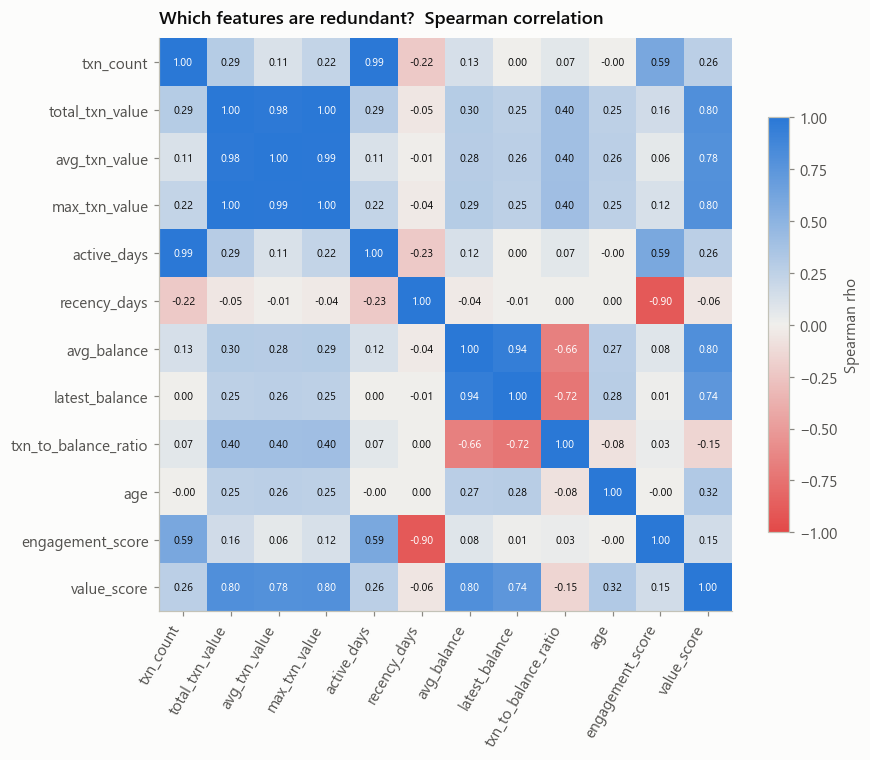

In [20]:
feats = ["txn_count", "total_txn_value", "avg_txn_value", "max_txn_value", "active_days", "recency_days",
         "avg_balance", "latest_balance", "txn_to_balance_ratio", "age", "engagement_score", "value_score"]
corr = c[feats].astype(float).corr(method="spearman")
fig, ax = plt.subplots(figsize=(8.4, 7))
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("div", [viz.DIVERGING[2], viz.DIVERGING[1], viz.DIVERGING[0]])
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(feats)), feats, rotation=60, ha="right"); ax.set_yticks(range(len(feats)), feats)
ax.grid(False)
for i in range(len(feats)):
    for j in range(len(feats)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color=viz.INK if abs(corr.values[i, j]) < 0.6 else "white")
fig.colorbar(im, ax=ax, shrink=0.7, label="Spearman rho")
ax.set_title("Which features are redundant?  Spearman correlation")
viz.save(fig, "P10_correlation"); fig

**What we found.** Several features are near-duplicates: total, average and maximum transaction value (rho 0.98-1.00), transaction count and active days (0.99), average and latest balance (0.94), and recency and engagement score (-0.90). Balance and transaction value are only moderately related (0.30).

**Why it matters.** Redundant inputs over-weight one idea in clustering. Balance and spend carry different information, so both belong in the model.

**What a manager should do.** (Analyst action.) Use one balance measure, total and average ticket (log-scaled), capped frequency and recency as clustering inputs; keep max value, active days and scores for profiling only.

## Statistical tests (spec 15)

With ~840K customers almost any difference is "significant", so every test reports an **effect size**
and the business reading rests on the effect size, not the p-value.

In [21]:
from scipy import stats
rows = []

# (a) Mann-Whitney U: average ticket, male vs female (skewed data); effect = rank-biserial r
m = g.loc[g.gender == "M", "avg_txn_value"]; f = g.loc[g.gender == "F", "avg_txn_value"]
u, p = stats.mannwhitneyu(m, f, alternative="two-sided")
rows.append(("Mann-Whitney U", "Avg ticket differs between men and women", f"U={u:,.0f}", p,
             "rank-biserial r", 1 - 2 * u / (len(m) * len(f)), f"median M Rs {m.median():,.0f} vs F Rs {f.median():,.0f}"))

# (b) Kruskal-Wallis: balance across age groups; effect = epsilon squared
known = c[c.age_group != "Unknown"].dropna(subset=["avg_balance"])
groups = [grp["avg_balance"].values for _, grp in known.groupby("age_group")]
h, p = stats.kruskal(*groups)
eps2 = (h - len(groups) + 1) / (len(known) - len(groups))
rows.append(("Kruskal-Wallis", "Avg balance differs across age groups", f"H={h:,.0f}", p, "epsilon²", eps2,
             "medians: " + ", ".join(f"{k} Rs {v:,.0f}" for k, v in known.groupby('age_group')['avg_balance'].median().items())))

# (c) Spearman: balance vs transaction value
bb = c.dropna(subset=["avg_balance"])
rho, p = stats.spearmanr(bb["avg_balance"], bb["total_txn_value"])
rows.append(("Spearman", "Balance is associated with transaction value", f"rho={rho:.3f}", p, "rho", rho, ""))

# (d) Chi-square: city tier x high-value flag (H4); effect = Cramer's V
ct = pd.crosstab(c.loc[c.city_tier != "Unknown", "city_tier"], c.loc[c.city_tier != "Unknown", "is_high_value"])
chi2, p, dof, _ = stats.chi2_contingency(ct)
v_ = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
hv_rate = (100 * ct[True] / ct.sum(axis=1)).round(1)
rows.append(("Chi-square", "High-value share differs by city tier", f"chi2={chi2:,.0f}, dof={dof}", p, "Cramer's V", v_,
             "high-value %: " + ", ".join(f"{k} {v}%" for k, v in hv_rate.items())))

tests = pd.DataFrame(rows, columns=["test", "hypothesis (H1 of the test)", "statistic", "p_value", "effect", "effect_size", "detail"])
tests["p_value"] = tests["p_value"].map(lambda x: "< 1e-300" if x == 0 else f"{x:.2e}")
tests.to_csv(ROOT / "outputs" / "stat_tests.csv", index=False)
tests

,test,hypothesis (H1 of the test),statistic,p_value,effect,effect_size,detail
0,Mann-Whitney U,Avg ticket differs between men and women,"U=63,717,136,297",< 1e-300,rank-biserial r,0.08,median M Rs 473 vs F Rs 560
1,Kruskal-Wallis,Avg balance differs across age groups,"H=49,822",< 1e-300,epsilon²,0.06,"medians: 18-24 Rs 9,741, 25-34 Rs 17,614, 35-4..."
2,Spearman,Balance is associated with transaction value,rho=0.296,< 1e-300,rho,0.30,
3,Chi-square,High-value share differs by city tier,"chi2=2,281, dof=2",< 1e-300,Cramer's V,0.05,"high-value %: Metro satellite 18.8%, Other 15...."


In [22]:
# Chi-square gender x segment (spec 15d) is in notebook 03, after segments exist.
hyp = pd.DataFrame([
    ("H1", "A small group holds a disproportionate share of balance",
     f"top 10% of customers hold {100 * b.nlargest(int(len(b) * .1)).sum() / b.sum():.1f}% of total latest balance"),
    ("H2", "Most customers are single-transaction, low-ticket",
     f"{100 * (c.txn_count == 1).mean():.1f}% single-transaction; their median ticket Rs {c.loc[c.txn_count == 1, 'avg_txn_value'].median():,.0f}"),
    ("H3", "Older customers hold higher balances",
     "median avg balance by age group: " + ", ".join(f"{k} Rs {v:,.0f}" for k, v in known.groupby('age_group')['avg_balance'].median().items())),
    ("H4", "Metro cities hold more high-value customers",
     "high-value share: " + ", ".join(f"{k} {v}%" for k, v in hv_rate.items())),
], columns=["id", "hypothesis", "evidence"])
hyp

,id,hypothesis,evidence
0,H1,A small group holds a disproportionate share o...,top 10% of customers hold 76.8% of total lates...
1,H2,"Most customers are single-transaction, low-ticket",84.6% single-transaction; their median ticket ...
2,H3,Older customers hold higher balances,"median avg balance by age group: 18-24 Rs 9,74..."
3,H4,Metro cities hold more high-value customers,"high-value share: Metro satellite 18.8%, Other..."


**Hypotheses, verdicts.**

| ID | Verdict | Evidence |
|---|---|---|
| H1 | **Supported** | Top 10% hold 76.8% of balance and 63.3% of transaction value |
| H2 | **Supported** | 84.6% single-transaction; their median ticket is Rs 460 (Rs 666 for repeat customers) |
| H3 | **Supported, modest effect** | Median balance rises steadily from Rs 9,741 (18-24) to Rs 54,368 (65+); Kruskal-Wallis epsilon² = 0.06 |
| H4 | **Weakly supported** | High-value share 19.8% in Tier 1 metros and 18.8% in metro satellites vs 15.5% elsewhere; Cramér's V = 0.05 |

All p-values are effectively zero because of the sample size; the effect sizes are small to moderate. The strongest structure in the data is **value concentration (H1)**, not demographics.